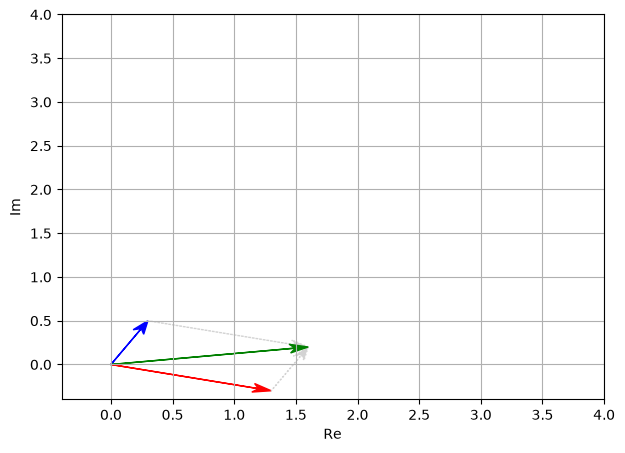

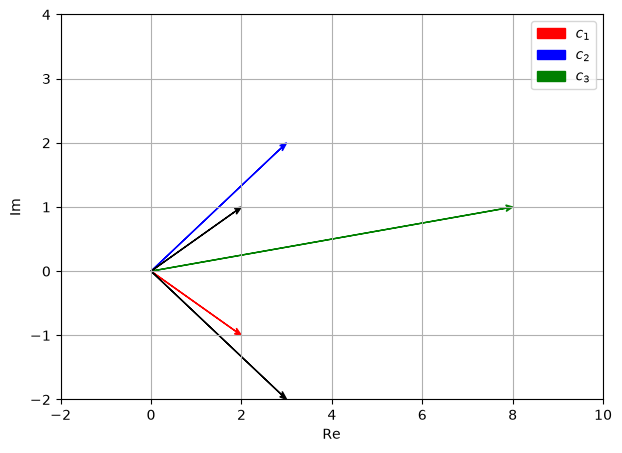

In [61]:
# complex numbers
import numpy as np
import matplotlib.pyplot as plt



def gen_figure(figsize=(2, 2), xlim=[0, 1], ylim =[0, 1]):
    """
    generate figure for plotting complex numbers
    """

    plt.figure(figsize=figsize)
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(r"$\mathrm{Re}$")
    plt.ylabel(r"$\mathrm{Im}$")

def plot_vec(c, color="k", start=0, linestyle="-"):
    """
    plot arrow that corresponds to the difference between 2 complex nums
    """

    return plt.arrow(
        np.real(start), np.imag(start), np.real(c), np.imag(c), linestyle=linestyle,
        head_width=0.1, fc=color, ec=color, overhang=0.3, length_includes_head=True
    )

c1 = 1.3 - 0.3j
c2 = 0.3 + 0.5j
c = c1 + c2
gen_figure(figsize=(7, 5), xlim=[-0.4, 4], ylim=[-0.4, 4])
v1 = plot_vec(c1, color="r")
v2 = plot_vec(c2, color="b")

plot_vec(c1, start=c2, linestyle=":", color="lightgray")
plot_vec(c2, start=c1, linestyle=":", color="lightgray")

plot_vec(c, color="g");

c3 = 2.0 - 1j
c4 = 3.0 + 2j
c3_conj = np.conj(c3)
c4_conj = np.conj(c4)
c = c3 * c4

gen_figure(figsize=(7, 5), xlim=[-2, 10], ylim=[-2, 4])
v1 = plot_vec(c3, color="r")
v2 = plot_vec(c4, color="b")
v3 = plot_vec(c, color="g")
v4 = plot_vec(c3_conj, color="black")
v5 = plot_vec(c4_conj, color="black")
plt.legend([v1, v2, v3], ["$c_1$", "$c_2$", "$c_3$"]);

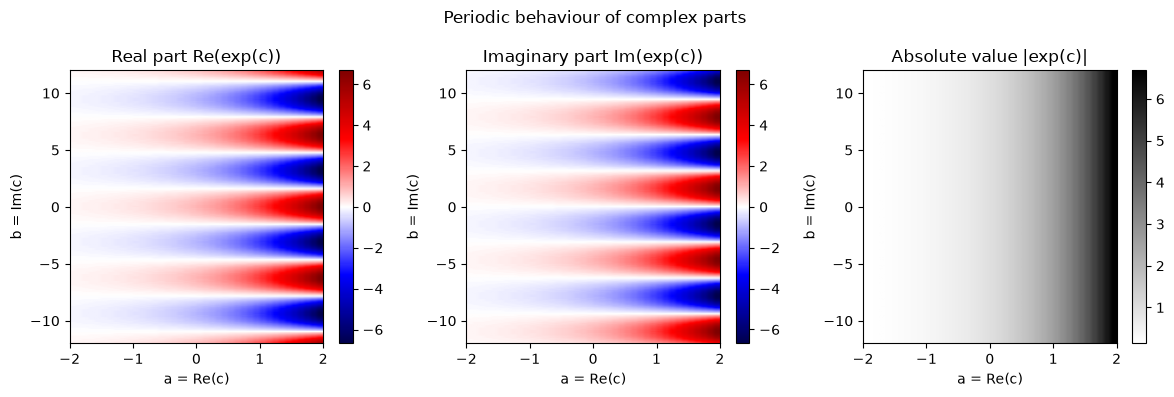

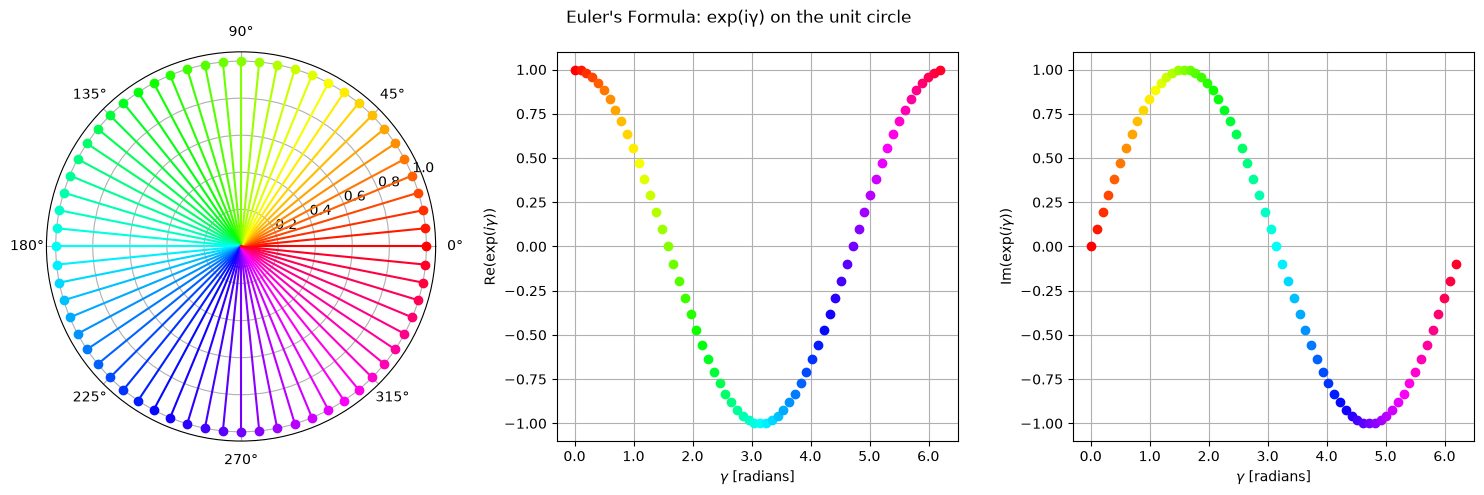

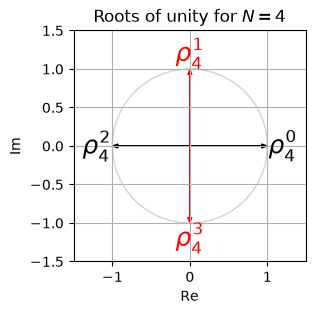

In [ ]:
# exponential function
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import sys
from math import gcd
import libfmp.c2
%matplotlib inline 

def exp_power_series(c, N):

    """
    c = Complex number
    N = Number of summands used for approx

    returns:
    exp_c = approximation of exp(c)
    """    

    exp_c = 1
    c_power = 1
    nfac = 1
    for n in range(1, N):

        nfac *= n
        c_power *= c 
        exp_c += c_power / nfac
        
    return exp_c

c=1
exp_power_series(1, 10)


A, B = np.meshgrid(np.arange(-2, 2, 0.1), np.arange(-12, 12, 0.1))

c = A + B*1j
f_exp = np.exp(c)

plt.figure(figsize=(12, 4))
plt.suptitle("Periodic behaviour of complex parts")
extent = [-2, 2, -12, 12]
plt.subplot(1, 3, 1)
plt.imshow(np.real(f_exp), aspect="auto", cmap="seismic", origin="lower", extent=extent)
plt.title("Real part Re(exp(c))")
plt.xlabel("a = Re(c)")
plt.ylabel("b = Im(c)")
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(np.imag(f_exp), aspect="auto", cmap="seismic", origin="lower", extent=extent)
plt.title("Imaginary part Im(exp(c))")
plt.xlabel("a = Re(c)")
plt.ylabel("b = Im(c)")
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(np.abs(f_exp), aspect="auto", cmap="gray_r", origin="lower", extent=extent)
plt.title("Absolute value |exp(c)|")
plt.xlabel("a = Re(c)")
plt.ylabel("b = Im(c)")
plt.colorbar()
plt.tight_layout()


cmap = plt.get_cmap("hsv")

N = 64

fig = plt.figure(figsize=(5*3, 5))
plt.suptitle("Euler's Formula: $\mathrm{exp(i\gamma)}$ on the unit circle")
ax1 = fig.add_subplot(1, 3, 1, projection="polar")
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

for i in range(N):
    gamma = 2 * np.pi * i / N
    c = np.exp(1j * gamma)
    color = cmap(i / N)
    ax1.plot([0, np.angle(c)], [0, np.abs(c)], "-", color=color)
    ax1.plot(np.angle(c), np.abs(c), "o", color=color)
    ax2.plot(gamma, np.real(c), "o", color=color)
    ax3.plot(gamma, np.imag(c), "o", color=color)

ax2.grid()
ax2.set_xlabel("$\gamma$ [radians]")
ax2.set_ylabel("$\mathrm{Re}(\exp(i \gamma))$")
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter("$%s$"))

ax3.grid()
ax3.set_xlabel("$\gamma$ [radians]")
ax3.set_ylabel("$\mathrm{Im}(\exp(i \gamma))$")
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter("$%s$"))
plt.tight_layout()

def plot_root_unity(N, figsize=(3, 3)):
    root_unity = np.exp(2j * np.pi / N)
    root_unity_power = 1

    _, ax = plt.subplots(figsize=figsize)
    plt.grid()
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.xlabel("$\mathrm{Re}$")
    plt.ylabel("$\mathrm{Im}$")
    plt.title("Roots of unity for $N=%d$"%N)

    for n in range(0, N):
        colorPlot = "r" if gcd(n, N) == 1 else "k"
        libfmp.c2.plot_vector(root_unity_power, color=colorPlot)
        plt.text(np.real(1.2*root_unity_power), np.imag(1.2*root_unity_power),

            r"$\rho_{%s}^{%s}$" % (N, n), size="18",
            color=colorPlot, ha="center", va="center")
        root_unity_power *= root_unity

    circle_unit = plt.Circle((0, 0), 1, color="lightgray", fill=0)
    ax.add_artist(circle_unit)

plot_root_unity(N=4)

Vectors of high similarity: 3.801315561749642
Vectors of low similarity: 0.10100495037373167


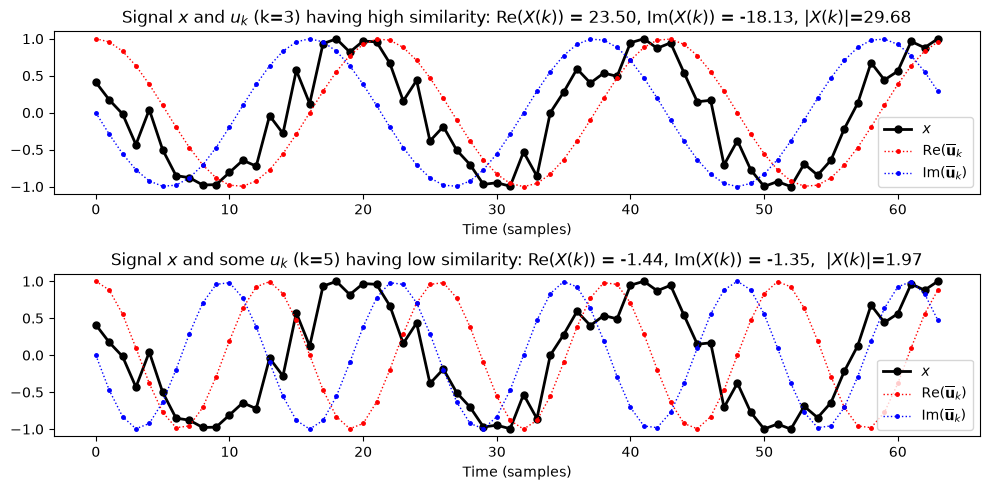

In [ ]:
# DFT

import numpy as np
from matplotlib import pyplot as plt
from numba import jit

x = np.array([1.0, 1j, 1.0 + 1.0j])
y = np.array([0.9, 1j, 1.0 + 0.9j])

print(f"Vectors of high similarity: {np.abs(np.vdot(x, y))}")

x = np.array([1.0, 1j, 1.0 + 1j])
y = np.array([1.1, -1j, 0.001])

print(f"Vectors of low similarity: {np.abs(np.vdot(x, y))}")

N = 64
n = np.arange(N)
k = 3
x = np.cos(2 * np.pi * (k * n / N) + (1.2*np.random.rand(N) - 0.0))

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(n, x, "k", marker=".", markersize="10", linewidth=2.0, label = "$x$")

plt.xlabel("Time (samples)")
k = 3
u_k_real = np.cos(2 * np.pi * k * n / N)
u_k_imag = -np.sin(2 * np.pi * k * n / N)

u_k = u_k_real + 1j*u_k_imag

sim_complex = np.vdot(u_k, x)
sim_abs = np.abs(sim_complex)

plt.title(r"Signal $x$ and $u_k$ (k=3) having high similarity: Re($X(k)$) = %0.2f, Im($X(k)$) = %0.2f, $|X(k)|$=%0.2f"%(sim_complex.real, sim_complex.imag, sim_abs))
plt.plot(n, u_k_real, "r", marker=".", markersize="5",
         linewidth=1.0, linestyle=":", label="$\mathrm{Re}(\overline{\mathbf{u}}_k$"
         );

plt.plot(n, u_k_imag, 'b', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Im}(\overline{\mathbf{u}}_k)$');

plt.legend()

plt.subplot (2, 1, 2)
plt.plot(n, x, "k", marker=".", markersize="10", linewidth=2.0, label="$x$")
plt.xlabel("Time (samples)")
k = 5
u_k_real = np.cos(2 * np.pi * k * n / N)
u_k_imag = -np.sin(2 * np.pi * k * n / N)
u_k = u_k_real + u_k_imag*1j
sim_complex = np.vdot(u_k, x)
sim_abs = np.abs(sim_complex)

plt.title(r'Signal $x$ and $u_k$ (k=5) having low similarity: Re($X(k)$) = %0.2f, Im($X(k)$) = %0.2f,  $|X(k)|$=%0.2f'%(sim_complex.real,sim_complex.imag,sim_abs))

plt.plot(n, u_k_real, 'r', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Re}(\overline{\mathbf{u}}_k)$');
plt.plot(n, u_k_imag, 'b', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Im}(\overline{\mathbf{u}}_k)$');
plt.legend()

plt.tight_layout()